# 1. Preprocess

## 1.1. Images

- Crop images to remove unnecessary white margins.
- Resize images to a fixed size (e.g., 384x384 pixels) while maintaining aspect ratio (thumbnailing + padding).
- Convert images to grayscale to reduce complexity (but the channel dim is still 3).
- Apply data augmentation techniques when training.
- Normalize with mean and standard deviation of the dataset (UniMER).
- Convert images to tensors.

## 1.2. LaTeX Sequences

- Tokenize LaTeX sequences using a custom tokenizer. Convert LaTeX commands and symbols into unique tokens.
- Each token is mapped to a unique integer ID.

# 2. Model Architecture
## 2.1. Encoder: HGNet-V2

The encoder is a CNN based on HGNet-V2 architecture, designed for efficient feature extraction from images. It uses hierarchical grouping of convolutional layers with layer aggregation and squeeze-and-excitation mechanisms.
- ConvBNAct: Convolution + BatchNorm + ReLU
- LightConvBNAct: Depthwise Separable Convolution + BatchNorm + ReLU

The encoder consists of a Stem followed by 4 Stages.

- Stem Block (StemBlock):

  - Function: Performs aggressive initial downsampling to reduce the spatial resolution of the input image (384x384) early on, saving computation for later stages.
  - Structure: It consists of multiple ConvBNAct layers (Convolution + BatchNorm + ReLU) and a MaxPool layer.
    - Input shape: (B, 3, 384, 384)
    - Output shape: (B, 48, 96, 96)


- Hierarchical Stages (HG_Stage):

  - The network has 4 stages.

  - The Building Block: HG Block (HG_Block):
    - Lightweight Convolution: It uses LightConvBNAct, which implements Depthwise Separable Convolutions (1x1 Pointwise Conv followed by a grouped KxK Depthwise Conv). This reduces parameter count and computation compared to standard convolutions.
    - Layer Aggregation: Inside a block, it stacks multiple layers. Crucially, it concatenates the outputs of all layers in the block (torch.cat(output, dim=1)).
    - Squeeze-and-Excitation: After concatenation, it uses 1x1 convolutions (aggregation_squeeze_conv and aggregation_excitation_conv) to fuse the aggregated features back to the target channel dimension.
    - Residual Connection if configured.

  - Each stage consists of a downsampling layer (except the first) followed by a stack of HG Blocks.
    - Stage 1: (using 1 HG Block with 6 layers of 3x3 ConvBNAct, then aggregating from those layers to 128 channels)
      - Input: (B, 48, 96, 96)
      - Output: (B, 128, 96, 96)
    - Stage 2: (using 1 HG Block with 6 layers of 3x3 ConvBNAct, preceded by a downsampling layer (ConvBNAct with kernel_size=3 and stride=2), then aggregating from those layers to 512 channels)
      - Input: (B, 128, 96, 96)
      - Output: (B, 512, 48, 48)  
    - Stage 3: (using 3 HG Block with 6 layers of 5x5 LightConvBNAct, preceded by a downsampling layer)
      - Input: (B, 512, 48, 48)
      - Output: (B, 1024, 24, 24)
    - Stage 4: (using 1 HG Block with 6 layers of 5x5 LightConvBNAct, preceded by a downsampling layer)
      - Input: (B, 1024, 24, 24)
      - Output: (B, 2048, 12, 12)
  - Final transformation (flatten): (B, 2048, 12, 12) -> (B, 2048, 144) -> (B, 144, 2048) 


  -> **OUTPUT: (B, 144, 2048)**
## 2.2. The Bridge between Encoder and Decoder: Linear Projection Layer
- A linear layer that projects the encoder output features to match the decoder's expected input dimension.
- (B, N, C_encoder) -> (B, N, C_decoder) or (B, N, 2048) -> (B, N, 384) in the current configuration.

  -> **Output: (B, 144, 384)**
## 2.3. Decoder: MBart (tiny version)
- The decoder receives a "Start of Sentence" token (&lt;s&gt;).
- Self-attention: The decoder attends to previously generated tokens (masked self-attention) to maintain syntactic coherence.
- Cross-attention: The decoder attends to the Bridge Output (the 144 visual feature vectors). This is where the model "looks" at specific parts of the image (e.g., the numerator of a fraction) to decide what token to generate next.
- Feed Forward: Processes the attended information.
- A linear layer projects the hidden state (384) to the vocabulary size (687).
- Calculates probabilities for the next token by applying a softmax function to the output logits.
- The selected token is fed back in as input for the next step until an "End of Sentence" token (&lt;/s&gt;) is generated.

In [1]:
from texo.data.processor import EvalMERImageProcessor
from texo.model.formulanet import FormulaNet
from transformers import (
    AutoTokenizer,
    VisionEncoderDecoderModel,
    PreTrainedTokenizerFast,
)
from PIL import Image
import IPython
import torch
import torchinfo

/data/CiCi/code/projects/uit/cs231/.venv/lib/python3.13/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def load(path):
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = VisionEncoderDecoderModel.from_pretrained(path)

    print(
        f"""Tokenizer info:
    - type: {type(tokenizer).__name__},
    - vocab_size: {tokenizer.vocab_size},
    - special_tokens: {tokenizer.special_tokens_map},
    - added_tokens: {tokenizer.added_tokens_encoder},
        """
    )
    print(torchinfo.summary(model, depth=3))

    return model, tokenizer

In [3]:
def inference(
    model: FormulaNet,
    image_path: str | Image.Image,
    tokenizer: PreTrainedTokenizerFast,
    device,
):
    model.to(device)
    image = Image.open(image_path) if isinstance(image_path, str) else image_path
    image_processor = EvalMERImageProcessor(image_size={"width": 384, "height": 384})
    processed_image = image_processor(image).unsqueeze(0)
    outputs = model.generate(pixel_values=processed_image.to(device))
    pred_str = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return pred_str

In [4]:
model, tokenizer = load("alephpi/FormulaNet")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Tokenizer info:
    - type: PreTrainedTokenizerFast,
    - vocab_size: 687,
    - special_tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'},
    - added_tokens: {'<s>': 0, '<pad>': 1, '</s>': 2, '<unk>': 3},
        
Layer (type:depth-idx)                                            Param #
VisionEncoderDecoderModel                                         --
├─HGNetv2: 1-1                                                    --
│    └─StemBlock: 2-1                                             --
│    │    └─ConvBNAct: 3-1                                        928
│    │    └─ConvBNAct: 3-2                                        2,080
│    │    └─ConvBNAct: 3-3                                        2,112
│    │    └─ConvBNAct: 3-4                                        18,496
│    │    └─ConvBNAct: 3-5                                        1,632
│    │    └─MaxPool2d: 3-6                                        --
│    └─ModuleList: 2-2        

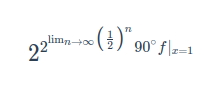

2 ^ { 2 ^ { \operatorname* { l i m } _ { n \rarr \infin } \left ( { \frac { 1 } { 2 } } \right ) ^ { n } } 9 0 ^ { \circ } f | _ { x = 1 } }


In [5]:
image_path = "../data/test_img/a.png"
display(IPython.display.Image(image_path))
pred_str = inference(model, image_path, tokenizer, device)
print(pred_str)

$$
2 ^ { 2 ^ { \operatorname* { l i m } _ { n \rarr \infin } \left ( { \frac { 1 } { 2 } } \right ) ^ { n } } 9 0 ^ { \circ } f | _ { x = 1 } }
$$


$$
\int _ { 0 } ^ { r _ { 0 } } r d r ( \tilde { T } _ { _ { ( 0 ) } r } ^ { \theta } + \tilde { T } _ { _ { ( 0 ) } r } ^ { r } ) = r _ { 0 } ^ { 2 } \tilde { T } _ { _ { ( 0 ) } r } ^ { r } ( r _ { 0 } ) = r _ { 0 } ^ { 2 } \left[ \frac { A ^ { 2 } ( r _ { 0 } ) } { 2 e ^ { 2 } } + \frac { \alpha } { 2 } \Lambda ^ { 2 } ( r _ { 0 } ) \right] .
$$

$$
{ \bf X } = q ^ { - \frac { A + 2 } { 2 } } x K ^ { - \frac { A + 2 } { 2 } } \Lambda ^ { - \frac { B } { 2 } } .
$$

$$
D _ { i j } ( x, y ) = \sum _ { \mathbf { k } } \frac { 1 } { 2 k } \left ( \delta _ { i j } + \frac { k _ { i } k _ { j } } { { k _ { 3 } } ^ { 2 } } \right ) e ^ { i [ \mathbf { k } \cdot ( \mathbf { x } - \mathbf { y } ) - k | x _ { 0 } - y _ { 0 } | ] },
$$

$$
\mathbf { X } = q ^ { - \frac { A + 2 } { 8 } } x K ^ { - \frac { A + 2 } { 2 } } \Lambda ^ { - \frac { B } { 2 } }.$$

$$
\int _ { 0 } ^ { r _ { 0 } } r d r \big ( \tilde { T } _ { { ( 0 ) } ^ { \theta } { } ^ { \theta } } + \tilde { T } _ { { ( 0 ) } ^ { r } } ^ { r } \big ) = r _ { 0 } ^ { 2 } \tilde { T } _ { { ( 0 ) } ^ { r } } ^ { r } ( r _ { 0 } ) = r _ { 0 } ^ { 2 } \left [ \frac { A ^ { \prime 2 } ( r _ { 0 } ) } { 2 e ^ { 2 } } + \frac { \alpha } { 2 } \Lambda ^ { \prime 2 } ( r _ { 0 } ) \right ].
$$

In [6]:
import kagglehub
import os
import distance
import nltk
import numpy as np
from datasets import load_from_disk, Dataset

In [11]:
path = kagglehub.dataset_download("lthnhthngt/im2latex-100k")

print("Path to dataset files:", path)

Path to dataset files: /home/cici/.cache/kagglehub/datasets/lthnhthngt/im2latex-100k/versions/1


In [12]:
ds = load_from_disk(os.path.join(path, "dataset"))

In [13]:
test_set = ds["test"]

In [14]:
def exact_match_score(references, hypotheses):
    """Computes exact match scores.

    Args:
        references: list of list of tokens (one ref)
        hypotheses: list of list of tokens (one hypothesis)

    Returns:
        exact_match: (float) 1 is perfect

    """
    exact_match = 0
    for ref, hypo in zip(references, hypotheses):
        if np.array_equal(ref, hypo):
            exact_match += 1

    return exact_match / float(max(len(hypotheses), 1))


def bleu_score(references, hypotheses):
    """Computes bleu score.

    Args:
        references: list of list (one hypothesis)
        hypotheses: list of list (one hypothesis)

    Returns:
        BLEU-4 score: (float)

    """
    references = [[ref] for ref in references]  # for corpus_bleu func
    BLEU_4 = nltk.translate.bleu_score.corpus_bleu(
        references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25)
    )
    return BLEU_4


def edit_distance(references, hypotheses):
    """Computes Levenshtein distance between two sequences.

    Args:
        references: list of list of token (one hypothesis)
        hypotheses: list of list of token (one hypothesis)

    Returns:
        1 - levenshtein distance: (higher is better, 1 is perfect)

    """
    d_leven, len_tot = 0, 0
    for ref, hypo in zip(references, hypotheses):
        d_leven += distance.levenshtein(ref, hypo)
        len_tot += float(max(len(ref), len(hypo)))

    return 1.0 - d_leven / len_tot

In [15]:
gts = []
preds = []

# Use batched inference to speed up evaluation
model.eval()
image_processor = EvalMERImageProcessor(image_size={"width": 384, "height": 384})

batch_size = 16  # adjust based on your GPU memory
num_samples = len(test_set)

with torch.no_grad():
    for start in range(0, num_samples, batch_size):
        batch = test_set[start : start + batch_size]
        images = batch["image"]
        gt_strs = batch["formula"]

        processed_images = torch.stack([image_processor(img) for img in images]).to(
            device
        )
        outputs = model.generate(pixel_values=processed_images)
        pred_strs = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        gts.extend(s.split() for s in gt_strs)
        preds.extend(s.split() for s in pred_strs)

print("Exact Match:", exact_match_score(gts, preds))
print("BLEU-4:", bleu_score(gts, preds))
print("Edit Distance:", edit_distance(gts, preds))

Exact Match: 0.059830781627719584
BLEU-4: 0.7590276860874783
BLEU-4: 0.7590276860874783
Edit Distance: 0.7903247187651253
Edit Distance: 0.7903247187651253
